# colab

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [52]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

In [53]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [54]:
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [55]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [56]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label: 5


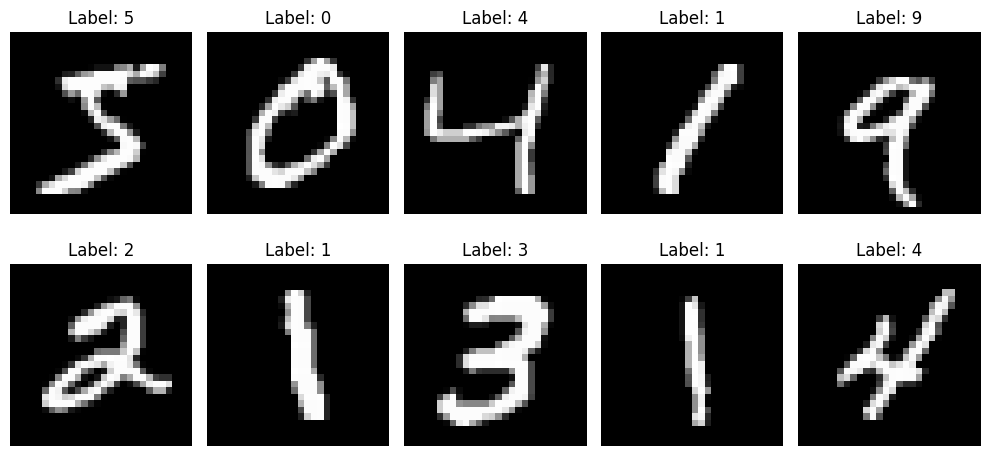

In [57]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    image, label = train_dataset[i]

    ax.imshow(
        image.squeeze(),
        cmap="gray"
    )

    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [58]:
class MNIST_CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.fc1 = nn.Linear(
            64 * 7 * 7,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = torch.relu(x)

        x = self.fc2(x)

        return x

In [59]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


Using device: cuda


In [60]:
model = MNIST_CNN().to(device)

print(model)


MNIST_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [61]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", total_params)

Total parameters: 421642


In [62]:
criterion = nn.CrossEntropyLoss()

In [63]:
optimizer = optim.SGD(
    model.parameters(),
    lr=0.001,
    # momentum=0.9
)

#Adam
# optimizer = optim.Adam(
#     model.parameters(),
#     lr=0.001
# )

In [64]:
epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    epoch_accuracy = (
        100 * correct / total
    )

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5] Loss: 1.8447 Accuracy: 59.23%
Epoch [2/5] Loss: 0.6510 Accuracy: 84.03%
Epoch [3/5] Loss: 0.4022 Accuracy: 88.80%
Epoch [4/5] Loss: 0.3342 Accuracy: 90.29%
Epoch [5/5] Loss: 0.2974 Accuracy: 91.29%


In [65]:
model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

test_accuracy = 100 * correct / total

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Accuracy: 92.13%


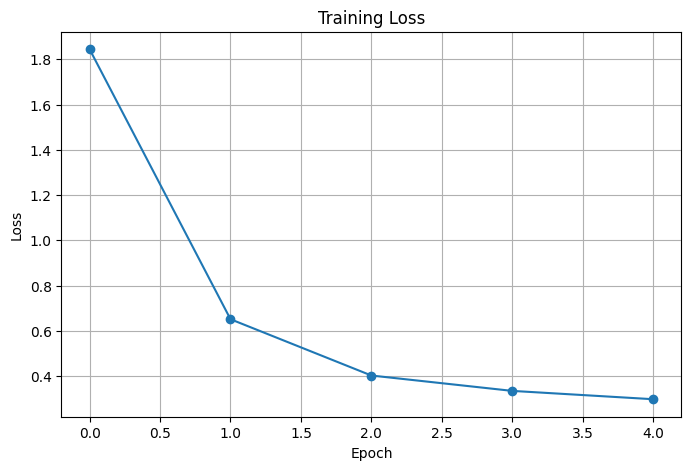

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid()
plt.show()

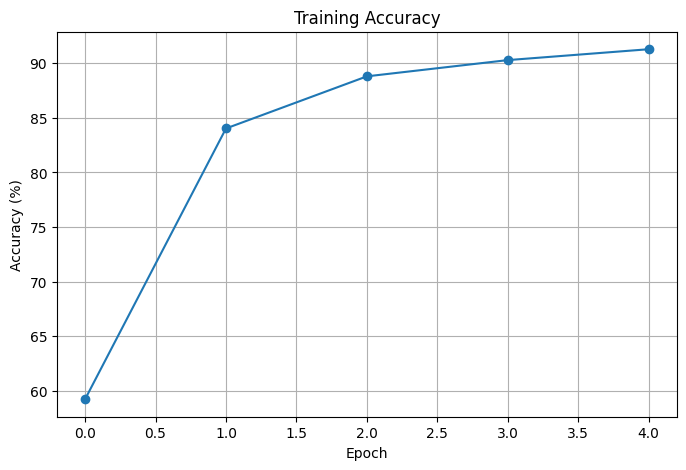

In [67]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.grid()
plt.show()

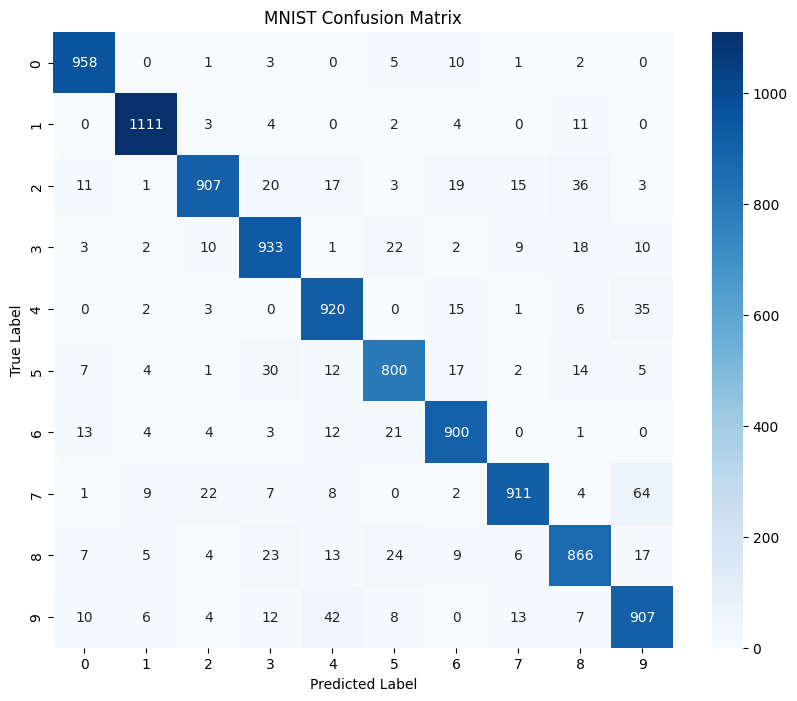

In [68]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")

plt.show()

In [69]:
print(
    classification_report(
        all_labels,
        all_predictions
    )
)

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.95      0.88      0.91      1032
           3       0.90      0.92      0.91      1010
           4       0.90      0.94      0.92       982
           5       0.90      0.90      0.90       892
           6       0.92      0.94      0.93       958
           7       0.95      0.89      0.92      1028
           8       0.90      0.89      0.89       974
           9       0.87      0.90      0.88      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



# **Eval**

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model, test_loader, device):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        average="weighted"
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        average="weighted"
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted"
    )

    print("===== MODEL EVALUATION =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_predictions
        )
    )

    return all_labels, all_predictions

In [79]:
all_labels, all_predictions = evaluate_model(
    model,
    test_loader,
    device
)

===== MODEL EVALUATION =====
Accuracy : 0.9213
Precision: 0.9218
Recall   : 0.9213
F1 Score : 0.9212

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.95      0.88      0.91      1032
           3       0.90      0.92      0.91      1010
           4       0.90      0.94      0.92       982
           5       0.90      0.90      0.90       892
           6       0.92      0.94      0.93       958
           7       0.95      0.89      0.92      1028
           8       0.90      0.89      0.89       974
           9       0.87      0.90      0.88      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



# **Accuracy report (Metrics (F1, ROC, confusion matrix))**

ROC

In [80]:
import torch.nn.functional as F

all_probabilities = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = F.softmax(
            outputs,
            dim=1
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

In [81]:
from sklearn.preprocessing import label_binarize

y_true = label_binarize(
    all_labels,
    classes=list(range(10))
)

In [82]:
import numpy as np

y_score = np.array(
    all_probabilities
)

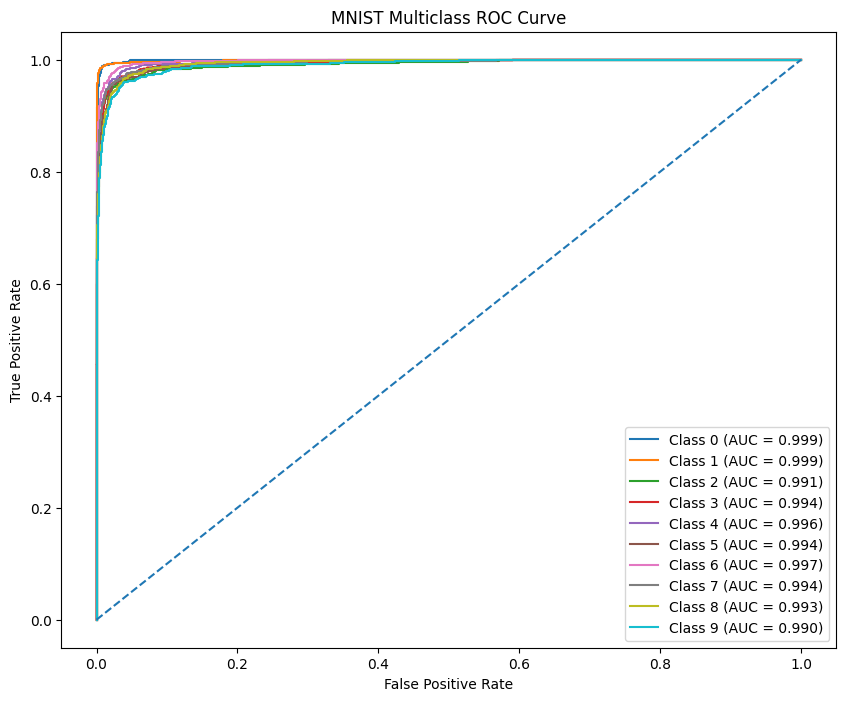

In [83]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

plt.figure(figsize=(10, 8))

for class_id in range(10):

    fpr, tpr, _ = roc_curve(
        y_true[:, class_id],
        y_score[:, class_id]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"Class {class_id} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("MNIST Multiclass ROC Curve")

plt.legend()

plt.show()

Overall ROC-AUC

In [84]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(
    y_true,
    y_score,
    multi_class="ovr",
    average="macro"
)

print(
    "Macro ROC-AUC:",
    macro_auc
)

Macro ROC-AUC: 0.9948705745949994
